In [1]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [ ]:
import os
from typing import List
import openai
from rank_bm25 import BM25Okapi
import numpy as np
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.docstore.document import Document
def replace_t_with_space(list_of_documents):
    """
    Replaces all tab characters ('\t') with spaces in the page content of each document

    Args:
        list_of_documents: A list of document objects, each with a 'page_content' attribute.

    Returns:
        The modified list of documents with tab characters replaced by spaces.
    """

    for doc in list_of_documents:
        doc.page_content = doc.page_content.replace('\t', ' ')  # Replace tabs with spaces
    return list_of_documents
def encode_pdf_and_get_split_documents(path, chunk_size=1000, chunk_overlap=200):
    """
    Encodes a PDF book into a vector store using OpenAI embeddings.

    Args:
        path: The path to the PDF file.
        chunk_size: The desired size of each text chunk.
        chunk_overlap: The amount of overlap between consecutive chunks.

    Returns:
        A FAISS vector store containing the encoded book content.
    """

    # Load PDF documents
    loader = PyPDFLoader(path)
    documents = loader.load()

    # Split documents into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap, length_function=len
    )
    texts = text_splitter.split_documents(documents)
    cleaned_texts = replace_t_with_space(texts)

    return cleaned_texts
def create_bm25_index(documents: List[Document]) -> BM25Okapi:
    """
    Create a BM25 index from the given documents.

    BM25 (Best Matching 25) is a ranking function used in information retrieval.
    It's based on the probabilistic retrieval framework and is an improvement over TF-IDF.

    Args:
    documents (List[Document]): List of documents to index.

    Returns:
    BM25Okapi: An index that can be used for BM25 scoring.
    """
    # Tokenize each document by splitting on whitespace
    # This is a simple approach and could be improved with more sophisticated tokenization
    tokenized_docs = [[w.lower() for w in doc.page_content.split()] for doc in documents]
    return BM25Okapi(tokenized_docs)

def retrieve_top_docs(query, cleaned_texts, k=10):
    bm25 = create_bm25_index(cleaned_texts)
    top_docs = bm25.get_top_n(query.lower().split(), cleaned_texts, n=k)
    return top_docs
def get_answer(query, docs_content, image_parts):
    client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "user", 
                "content": image_parts
            },
            {
                "role": "user",
                "content": "\n\n".join(docs_content)
            },
            {
                "role": "user", 
                "content": query
            }
        ]
    )
    answer = response.choices[0].message.content
    return answer

In [ ]:
from vision_rag_gpt5 import VisionRAG
from langgraph.prebuilt import create_react_agent
import os
query = "What does rule V.1.4.1 state exactly?"
rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")
cleaned_texts = encode_pdf_and_get_split_documents("dataset/docs/FSAE_Rules_2024_V1.pdf")

def retrieval(query: str, high_reasoning: bool = False):
    """Retrieve the answer from the documents using ColPali.
    
    Args:
        query (str): The user original question.
        high_reasoning (bool, optional): Whether to use high reasoning. Defaults to False.
    Returns:
        str: The answer to the user's question.
    """
    print("Calling ColPali retrieval"	)
    rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")

    answer = rag.answer_query(query, index_name="multimodal_rag_colqwen2.5-v0.2", k=15, api_key=os.getenv("OPENAI_API_KEY"), external_image_path=None, external_csv_path=None, prefer_csv_prompt=True, reasoning="medium" if not high_reasoning else "high")
    return answer

def hybrid_retrieval(query: str, keywords: str = None):
    """Retrieve the answer from the documents using both keyword search and ColPali, suitable for a specific term or definition-based questions.
    
    Args:
        query (str): The user original question.
        keywords (str, optional): The keywords to search for in the documents. Defaults to None.
    Returns:
        str: The answer to the user's question.
    """
    # Retrieve relevant documents
    print("Calling hybrid retrieval")
    top_docs = retrieve_top_docs(keywords.lower(), cleaned_texts, k=30)
    docs_content = [doc.page_content for doc in top_docs]

    rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")
    documents = rag.search(query, index_name="multimodal_rag_colqwen2.5-v0.2", k=10)
    image_parts = [
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{res.base64}"}}
        for res in documents
    ]

    # image_parts = []
    
    # Generate answer
    answer = get_answer(query, docs_content, image_parts)
    
    return answer
# answer = colpali_rag(query, k=5)
document_agent = create_react_agent(
    model="openai:gpt-5-nano",
    tools=[retrieval, hybrid_retrieval],
    prompt=(
        "You are a document agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with document retrieval-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="retrieval_agent",
)

In [8]:
for chunk in document_agent.stream(
    {"messages": [{"role": "user", "content": "What does rule V.1.4.1 state exactly?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: retrieval_agent
Tool Calls:
  retrieval (call_hnST81Hm4dCMrpiG31iCRGC7)
 Call ID: call_hnST81Hm4dCMrpiG31iCRGC7
  Args:
    query: What does rule V.1.4.1 state exactly?


Calling ColPali retrieval


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Update from node tools:


================================= Tool Message =================================
Name: retrieval

“Ground clearance must be sufficient to prevent any portion of the vehicle except the tires from touching the ground during dynamic events.”


Update from node agent:


================================== Ai Message ==================================
Name: retrieval_agent

Ground clearance must be sufficient to prevent any portion of the vehicle except the tires from touching the ground during dynamic events.




In [ ]:
from openai import OpenAI
import base64
import os
from pathlib import Path
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
system_prompt = """You are a meticulous vision-language assistant.
Your goal is to describe the provided plot image in such detail that someone
who cannot see it could still fully understand what it shows.

Your description must include:

1. **Overall figure**: type of chart (line, bar, scatter, etc.), title (if readable), 
   and general layout (single panel, multiple subplots, presence of colorbars).

2. **Axes**: 
   - Labels (exact text if legible, else say "unreadable")
   - Units (e.g., "mm", "seconds", "°C") or state "not specified"
   - Axis ranges and tick values (approximate if necessary)
   - Whether axes are linear, logarithmic, categorical, etc.

3. **Data series**:
   - How many series are present
   - Their styles (color, marker, line type)
   - Any labels in the legend (if visible)
   - Description of each series’ trend (e.g., rising, flat, peaks, correlations)

4. **Annotations and extras**:
   - Text labels, arrows, highlighted regions, error bars, shading
   - Gridlines, secondary axes, insets, or unusual features

5. **Trends & insights**:
   - Main relationships between x and y
   - Notable thresholds, turning points, or crossings between series
   - Comparative analysis of series (who dominates where)

6. **Uncertainties & missing info**:
   - If any text, axis labels, ticks, or legend entries are unreadable, state this
   - Mention what information is does not makes sense or is missing.

7. **Conclusions**:
   - all  key takeaways from the plot
   - Avoid speculation beyond the image

Output format:
---
JSON:

---
Report:

"""
def image_to_data_url(path: str) -> str:
    data = Path(path).read_bytes()
    b64 = base64.b64encode(data).decode("utf-8")
    return f"data:image/png;base64,{b64}"
def vision_analysis(query: str, img_path: str, high_reasoning: bool = False):
    """Analyze the given image in detail.
    
    Args:
        query (str): The user original question.
        img_path (str): The path to the image to analyze.
        high_reasoning (bool, optional): Whether to use high reasoning. Defaults to False.
        
    Returns:
        str: The answer to the user's question.
    """
    rag = VisionRAG(model_name="vidore/colqwen2.5-v0.2", device="cuda")
    data_url = image_to_data_url(img_path)
    response = client.chat.completions.create(
        model="gpt-5-nano",
        messages=[
            {"role": "system", "content": system_prompt},
            {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Please analyze this plot image with the above instructions."},
                        {"type": "image_url", "image_url": {"url": data_url}},
                    ],
                },
        ]
    )
    image_description = response.choices[0].message.content
    answer = rag.answer_query(
            query=query,
            index_name="multimodal_rag_colqwen2.5-v0.2",
            k=10,
            api_key=os.getenv("OPENAI_API_KEY"),
            imgDiscription=image_description,
            prefer_csv_prompt=True,
            max_completion_tokens=10512,
            reasoning="high" if high_reasoning else "medium",
        )
    return answer
vision_agent = create_react_agent(
    model="openai:gpt-5-nano",
    tools=[vision_analysis],
    prompt=(
        "You are an vision agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist with vision-related tasks, which requires both image analysis and document understanding\n"
        "- Turn on high reasoning for a very complex question"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="vision_agent",
)

In [10]:
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=init_chat_model("openai:gpt-5-mini"),
    agents=[vision_agent, document_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- an vision agent, helpful for analyzing any task that requires both image analysis and document understanding\n"
        "- a document retrieval agent, helpful for tasks without image input, but only retrieving information from the documents\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

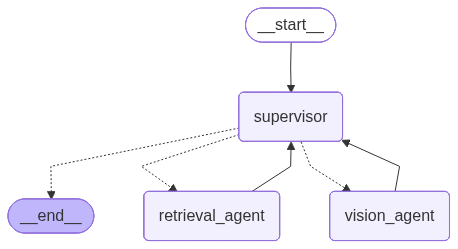

In [11]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [12]:
question = """
image_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.

"""
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                # "content": "What does rule V.1.4.1 state exactly?",
                "content": question
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_vision_agent

Successfully transferred to vision_agent




Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Update from node vision_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================== Ai Message ==================================
Name: supervisor

Explanation: F.3.5.3b gives the properties to use for non-welded 6061‑T6 in the SES: E ≈ 69 GPa, Sy ≈ 240 MPa, Su ≈ 290 MPa, and a minimum wall thickness of 2.0 mm for non‑welded tubing. Non‑welded 6061‑T6 tubing is permitted where F.3.2.1 allows alternative materials, but you must document the material, manufacturing method, and equivalency calculations in the Structural Equivalency Spreadsheet (SES) per F.3.5.2 and F.2. The attached FEA shows peak stresses around 220 MPa, which is below the non‑welded 6061‑T6 yield (≈240 MPa), so the shown stresses could be acceptable for non‑welded 6061‑T6. However, this conclusion depends on correct FEA assumptions, meeting the ≥

In [25]:
# question = """
# image_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.

# """
question = """
image_path = None
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
"""
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/mrv24001/miniconda3/envs/mdocagent/lib/python3.12/site-packages/torch/nn/modules/module.py:2409: UserWarning: for language_model.layers.23.mlp.down_proj.lora_A.default.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/mrv24001/miniconda3/envs/mdocagent/lib/python3.12/site-packages/torch/nn/modules/module.py:2409: UserWarning: for language_model.layers.23.mlp.down_proj.lora_B.default.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/mrv24001/miniconda3/envs/mdocagent/lib/python3.12/site-packages/torc

{'messages': [HumanMessage(content='\nimage_path = None\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.\n', additional_kwargs={}, response_metadata={}, id='bdd8b186-bcef-4a9b-b907-1b6449b41ed5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Ny4zqR0NexziIaevwCjDlM0B', 'function': {'arguments': '{}', 'name': 'transfer_to_retrieval_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 290, 'total_tokens': 377, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': 

In [13]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does rule V.1.4.1 state exactly?",
                # "content": question
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_retrieval_agent

Successfully transferred to retrieval_agent


Calling ColPali retrieval


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Update from node retrieval_agent:


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


Update from node supervisor:


================================== Ai Message ==================================
Name: supervisor

Rule V.1.4.1 states: "Ground clearance must be sufficient to prevent any portion of the vehicle except the tires from touching the ground during dynamic events."




In [28]:
message

{'messages': [HumanMessage(content='\nimage_path = None\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.\n', additional_kwargs={}, response_metadata={}, id='0ac810c0-404f-42c9-96fe-c278013d6844'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4zTMwFy65C5LcZhBOEng0IYV', 'function': {'arguments': '{}', 'name': 'transfer_to_retrieval_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 343, 'prompt_tokens': 278, 'total_tokens': 621, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint'

In [15]:
question = """
image_path: dataset/rule_compliance/rule_functional_performance_qa/images/2.png
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.
"""
# question = """
# image_path = None
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
# """
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'messages': [HumanMessage(content='\nimage_path: dataset/rule_compliance/rule_functional_performance_qa/images/2.png\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.\n', additional_kwargs={}, response_metadata={}, id='7522ec28-f1cc-4108-b6ca-791d54c94bbc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_r1h97QRA6NJk9ikwq2waTsko', 'function': {'arguments': '{}', 'name': 'transfer_to_vision_agent'}, 'type': 'function'}], 're

In [11]:
message

{'messages': [HumanMessage(content='\nimage_path: dataset/rule_compliance/rule_functional_performance_qa/images/2.png\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.\n', additional_kwargs={}, response_metadata={}, id='914d700e-882d-4cb7-b8e5-2857532b4168'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_1fW5MllS9hsKFebhmY3QEMFL', 'function': {'arguments': '{}', 'name': 'transfer_to_vision_agent'}, 'type': 'function'}], 're

In [12]:
question = """
image_path: dataset/rule_compliance/rule_functional_performance_qa/images/3.png
We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows information about the riders that can be accommodated in the vehicle. At the top of the image, there is general anthropomorphic information. Below that, there is information about the largest man and smallest woman our vehicle can accommodate. Based on the information presented in the image, does our vehicle comply with rule V.2.1.1 presented in the rule document? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response."""
# question = """
# image_path = None
# We are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Please list all rules relevant to `Aerodynamic/Aerodynamics`. Answer with only the rule numbers (i.e.: AA.1.1.1) separated by commas and no other words.
# """
message = supervisor.invoke({"messages": [{"role": "user", "content": question}]})
message["messages"][-1].content

'Explanation: The image provides explicit anthropometric data for the smallest woman (5th percentile female) and the largest man (95th percentile male), with complete measurements in metric and imperial units. The bottom tables list the exact dimensions for these extremes, illustrating that the cockpit can accommodate occupants across this defined range, which aligns with the general intent of rule V.2.1.1 to accommodate an anthropometric range for occupants.\n\nAnswer: Yes'

In [14]:
message

{'messages': [HumanMessage(content='\nimage_path: dataset/rule_compliance/rule_functional_performance_qa/images/3.png\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows information about the riders that can be accommodated in the vehicle. At the top of the image, there is general anthropomorphic information. Below that, there is information about the largest man and smallest woman our vehicle can accommodate. Based on the information presented in the image, does our vehicle comply with rule V.2.1.1 presented in the rule document? First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.', additional_kwargs={}, response_metadata={}, id='582c26e9-bef4-4bef-aff5-1725604d2825'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_j13VKMQAz39XBThnQANjDVrs', 'fun

In [15]:
final_message_history

[HumanMessage(content='\nimage_path = "dataset/rule_compliance/rule_functional_performance_qa/images/1.png"\nWe are a student engineering team designing a vehicle for the FSAE competition. Attached is the FSAE rules document. Also attached is an image that shows the results from an FEA simulation performed on the battery structure. The battery structure is made from non-welded 6061-T6 aluminum tubing. Based on the results presented in the image and rule F.3.5.3b in the rule document, can we use the battery structure in the vehicle?  First provide an explanation for your answer (begin it with ‘Explanation:’). Then provide just a yes/no answer (begin it with ‘Answer:’) that summarizes your response.\n\n', additional_kwargs={}, response_metadata={}, id='eca2b063-4852-4a2e-8533-1cb59c068597'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_00LD8OJD3SSZBQNrpfoJ3Tie', 'function': {'arguments': '{}', 'name': 'transfer_to_retrieval_agent'}, 'type': 'function'}], 'refusal